In [1]:
# Importing libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importing functions and models from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay 

In [13]:
# Importing the zipfile library to work with ZIP compressed files
import zipfile

#Opening the ZIP file that contains the dataset
with zipfile.ZipFile(r"C:\Users\HP 9480\OneDrive\Desktop\Sami folder\bank.zip") as z:
    
    #Reading the CSV file inside the ZIP archive
    df = pd.read_csv(z.open('bank.csv'), sep=';')

In [14]:
# Displaying the first 5 rows of the dataset
print(df.head())

# Displaying dataset information
print(df.info())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #  

In [15]:
# Creating an object of LabelEncoder
le = LabelEncoder()

# Looping through all columns in the dataset
for col in df.columns:

    # Checking if the column data type is objective
    if df[col].dtype == 'object':

        # Converting text values into encoded numeric values
        df[col] = le.fit_transform(df[col])

In [16]:
# Separating input features and target variable
X = df.drop("y",axis=1)
y = df["y"]

In [17]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Create a Random Forest Classifier model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [19]:
# Making predictions using the trained model
predictions = model.predict(X_test)

In [20]:
# Printing the classification report to evaluate model performance
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       807
           1       0.55      0.31      0.39        98

    accuracy                           0.90       905
   macro avg       0.73      0.64      0.67       905
weighted avg       0.88      0.90      0.88       905



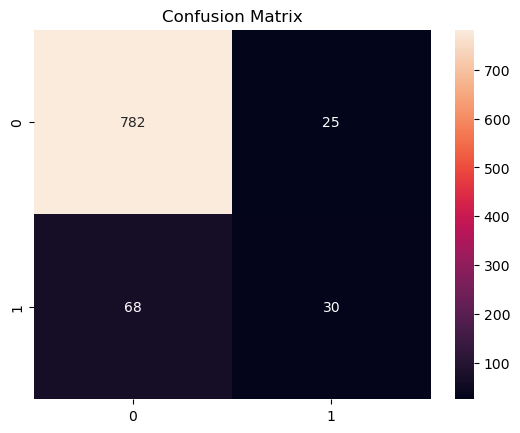

In [21]:
# Creating and visualizing the confusion matrix to evaluate the model's prediction performance
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

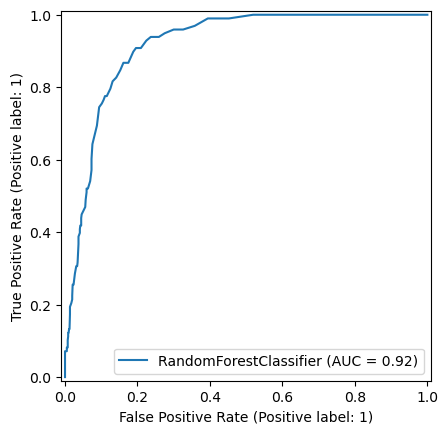

In [22]:
# Plot and display the ROC curve to evaluate the model's classification performance
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()